In [6]:
import json
import pickle
import re
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sklearn_crfsuite
from sklearn_crfsuite import metrics as crf_metrics
from sklearn.model_selection import train_test_split
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

### Access the data

In [7]:
data_dir = Path('..\..\datasets\processed_data')

with open(data_dir / 'processed.pkl', 'rb') as f:
    processed = pickle.load(f)

with open(data_dir / 'vocabs.pkl', 'rb') as f:
    v = pickle.load(f)
    token2id = v['token2id'];   id2token   = v['id2token']
    label2id = v['label2id'];   id2label   = v['id2label']
    char2id = v['char2id'];    id2char    = v['id2char']
    PAD_ID = v['PAD_ID'];     UNK_ID     = v['UNK_ID']
    PAD_LABEL_ID = v['PAD_LABEL_ID']
    Entity_labels = v['Entity_labels']
    MAX_LEN_LSTM = v['MAX_LEN_LSTM']
    MAX_LEN_BERT = v['MAX_LEN_BERT']

### Feature Engineering

In [8]:
# Lightweight regex POS tagger (no external dependency)
# Covers the most discriminative POS patterns for resume NER.
# In production, replace with spaCy: nlp(text).pos_

_POS_RULES = [
    (re.compile(r'^\d{4}$'),                  'CD_YEAR'),   # graduation year
    (re.compile(r'^\d+$'),                    'CD'),        # other digits
    (re.compile(r'^[A-Z][a-z]+$'),            'NNP'),       # TitleCase → proper noun
    (re.compile(r'^[A-Z]{2,}$'),              'NNP_ABB'),   # ALLCAPS → abbreviation
    (re.compile(r'.+ing$',re.I),              'VBG'),       # gerund
    (re.compile(r'.+ed$',re.I),               'VBD'),       # past tense
    (re.compile(r'.+er$',re.I),               'NN_ER'),     # developer, manager
    (re.compile(r'.+ly$',re.I),               'RB'),        # adverb
    (re.compile(r'.+tion$|.+sion$',re.I),     'NN_TION'),   # graduation, solution
    (re.compile(r'.+ment$',re.I),             'NN_MENT'),   # management
    (re.compile(r'@'),                        'EMAIL'),
    (re.compile(r'[+#]|\d'),                  'TECH'),      # C++, HTML5
]

def regex_pos(token: str) -> str:
    for pattern, tag in _POS_RULES:
        if pattern.search(token):
            return tag
    return 'NN'   # default: common noun


# Dual-token feature 

def align_raw_norm(raw_bio, norm_bio):
    """Pair each normalized token back to its original raw form."""
    aligned = []
    raw_iter = iter(raw_bio)
    for norm_tok, norm_tag in norm_bio:
        for raw_tok, raw_tag in raw_iter:
            if raw_tag == norm_tag:
                aligned.append((raw_tok, norm_tok, norm_tag))
                break
    return aligned


def token_features(raw_tok: str, norm_tok: str,
                   idx: int, raw_seq: list, norm_seq: list) -> dict:
    """
    Build CRF feature dictionary for one token.

    Orthographic flags  -> raw_tok  (casing / punctuation intact)
    Prefix/suffix       -> norm_tok (consistent normalized form)
    POS tag             -> raw_tok  (regex-based)
    Context window      -> both raw neighbours
    """
    prev_raw = raw_seq[idx - 1] if idx > 0 else '<START>'
    next_raw = raw_seq[idx + 1] if idx < len(raw_seq) - 1 else '<END>'

    feat = {
        # Identity 
        'token'            : norm_tok,
        'pos'              : regex_pos(raw_tok),

        # Orthographic (raw) 
        'is_title_case'    : raw_tok.istitle(),
        'is_all_upper'     : raw_tok.isupper(),
        'is_all_lower'     : raw_tok.islower(),
        'is_digit'         : raw_tok.isdigit(),
        'has_digit'        : any(c.isdigit() for c in raw_tok),
        'is_alnum'         : raw_tok.isalnum(),
        'has_hyphen'       : '-' in raw_tok,
        'has_at'           : '@' in raw_tok,
        'has_dot'          : '.' in raw_tok,
        'has_plus'         : '+' in raw_tok,
        'has_slash'        : '/' in raw_tok,

        # Shape 
        'token_length'     : len(raw_tok),
        'is_short'         : len(raw_tok) <= 2,

        # Prefix / suffix (normalized) 
        'prefix2'          : norm_tok[:2],
        'prefix3'          : norm_tok[:3],
        'prefix4'          : norm_tok[:4],
        'suffix2'          : norm_tok[-2:],
        'suffix3'          : norm_tok[-3:],
        'suffix4'          : norm_tok[-4:],

        # Context bigrams (raw)
        'prev_token'       : prev_raw.lower(),
        'prev_is_title'    : prev_raw.istitle(),
        'prev_is_upper'    : prev_raw.isupper(),
        'prev_pos'         : regex_pos(prev_raw),
        'next_token'       : next_raw.lower(),
        'next_is_title'    : next_raw.istitle(),
        'next_is_upper'    : next_raw.isupper(),
        'next_pos'         : regex_pos(next_raw),

        # Position
        'is_sentence_start': idx == 0,
        'is_sentence_end'  : idx == len(raw_seq) - 1,
    }
    return feat


def sequence_features(raw_bio, norm_bio):
    aligned = align_raw_norm(raw_bio, norm_bio)
    raw_toks = [r for r, _, _ in aligned]
    norm_toks = [n for _, n, _ in aligned]
    return [
        token_features(raw_toks[i], norm_toks[i], i, raw_toks, norm_toks)
        for i in range(len(aligned))
    ]

# Demo
demo_feats = sequence_features(
    processed[0]['word_bio_raw'],
    processed[0]['word_bio_norm']
)
show_keys = ['token','pos','is_title_case','is_all_upper','is_digit','has_at','prefix3','suffix3','prev_token','next_token']
demo_tags = [tag for _,tag in processed[0]['word_bio_norm']]

print(f"{'BIO Tag':<28}" + ''.join(f"{k:<18}" for k in show_keys))
print("=" * (28 + 18 * len(show_keys)))
for tag, feat in zip(demo_tags[:10], demo_feats[:10]):
    print(f"{tag:<28}" + ''.join(f"{str(feat[k]):<18}" for k in show_keys))

BIO Tag                     token             pos               is_title_case     is_all_upper      is_digit          has_at            prefix3           suffix3           prev_token        next_token        
B-Name                      abhishek          NNP               True              False             False             False             abh               hek               <start>           jha               
I-Name                      jha               NNP               True              False             False             False             jha               jha               abhishek          application       
B-Designation               application       NNP               True              False             False             False             app               ion               jha               development       
I-Designation               development       NNP               True              False             False             False             dev               ent       

### Building Dataset

In [9]:
# Build X (feature sequences) and y (label sequences) for all resumes
X_all, y_all = [], []

for p in processed:
    feats = sequence_features(p['word_bio_raw'], p['word_bio_norm'])
    labels = [tag for _, tag in p['word_bio_norm']]
    X_all.append(feats)
    y_all.append(labels)

print(f"Sequences : {len(X_all)}")
print(f"Avg length: {sum(len(s) for s in X_all)/len(X_all):.1f} tokens")
print(f"Features per token: {len(X_all[0][0])}")

Sequences : 220
Avg length: 485.4 tokens
Features per token: 31


In [10]:
# Train / Validation / Test split  (70 / 15 / 15)
from sklearn.model_selection import train_test_split

indices = list(range(len(X_all)))
idx_train, idx_temp = train_test_split(indices, test_size=0.30, random_state=42)
idx_val,   idx_test = train_test_split(idx_temp,  test_size=0.50, random_state=42)

X_train = [X_all[i] for i in idx_train]
y_train = [y_all[i] for i in idx_train]
X_val = [X_all[i] for i in idx_val]
y_val = [y_all[i] for i in idx_val]
X_test = [X_all[i] for i in idx_test]
y_test = [y_all[i] for i in idx_test]

print(f"Train : {len(X_train)} resumes  ({len(X_train)/len(X_all)*100:.0f}%)")
print(f"Val   : {len(X_val)}  resumes  ({len(X_val)/len(X_all)*100:.0f}%)")
print(f"Test  : {len(X_test)}  resumes  ({len(X_test)/len(X_all)*100:.0f}%)")

Train : 154 resumes  (70%)
Val   : 33  resumes  (15%)
Test  : 33  resumes  (15%)


Save split data (Supaya dat ayang diapke buat semua model sama)

In [11]:
# Save split indices — run ONCE, all other models load this
split = {
    'idx_train': idx_train,
    'idx_val'  : idx_val,
    'idx_test' : idx_test,
}

split_dir = Path('../../datasets/split_data')
split_dir.mkdir(exist_ok=True)

with open(split_dir / 'split_indices.json', 'w') as f:
    json.dump(split, f)

print("Split saved -> split_indices.json")
print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

Split saved -> split_indices.json
Train: 154 | Val: 33 | Test: 33


### Hyperparameter Tuning

In [12]:
from itertools import product

c1_values = [0.01, 0.1, 0.5]
c2_values = [0.01, 0.1, 0.5]
MAX_ITER = 100

grid_results = []

print(f"Grid search: {len(c1_values)}×{len(c2_values)} = {len(c1_values)*len(c2_values)} combos")
print(f"{'c1':<8} {'c2':<8} {'Val F1':>10}")
print("=" * 30)

for c1, c2 in product(c1_values, c2_values):
    crf = sklearn_crfsuite.CRF(
        algorithm='lbfgs',
        c1=c1,
        c2=c2,
        max_iterations=MAX_ITER,
        all_possible_transitions=True
    )
    crf.fit(X_train, y_train)
    y_pred_val = crf.predict(X_val)
    f1 = f1_score(y_val, y_pred_val)
    grid_results.append({'c1': c1, 'c2': c2, 'val_f1': f1})
    print(f"{c1:<8} {c2:<8} {f1:>10.4f}")

best = max(grid_results, key=lambda x: x['val_f1'])
print(f"\nBest -> c1={best['c1']}, c2={best['c2']}, val_f1={best['val_f1']:.4f}")

Grid search: 3×3 = 9 combos
c1       c2           Val F1
0.01     0.01         0.5507
0.01     0.1          0.5551
0.01     0.5          0.5603
0.1      0.01         0.5815
0.1      0.1          0.5863
0.1      0.5          0.5546
0.5      0.01         0.5841
0.5      0.1          0.5802
0.5      0.5          0.5860

Best -> c1=0.1, c2=0.1, val_f1=0.5863


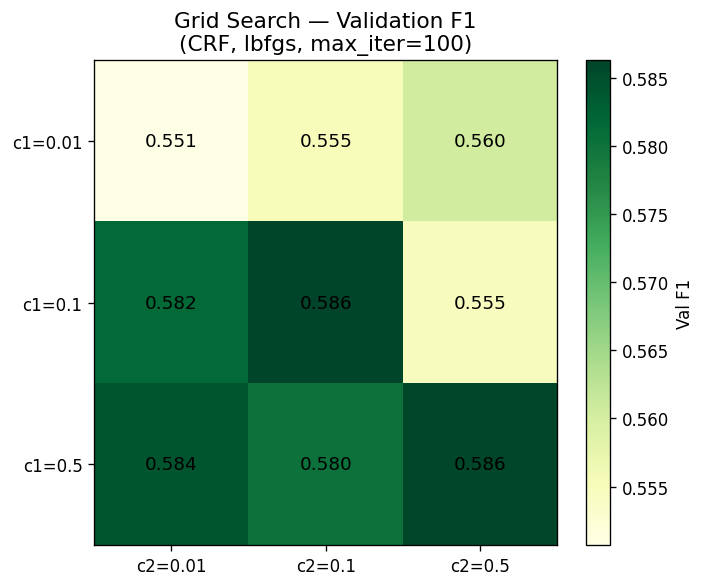

In [13]:
# Visualise grid search heatmap
grid_df = pd.DataFrame(grid_results)
pivot = grid_df.pivot(index='c1', columns='c2', values='val_f1')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(c2_values)))
ax.set_yticks(range(len(c1_values)))
ax.set_xticklabels([f"c2={v}" for v in c2_values])
ax.set_yticklabels([f"c1={v}" for v in c1_values])
for i in range(len(c1_values)):
    for j in range(len(c2_values)):
        ax.text(j, i, f"{pivot.values[i,j]:.3f}", ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, label='Val F1')
ax.set_title("Grid Search — Validation F1\n(CRF, lbfgs, max_iter=100)")
plt.tight_layout()
plt.show()

### Train Model

In [14]:
# Train with best hyperparameters on train+val
X_trainval = X_train + X_val
y_trainval = y_train + y_val

crf_final = sklearn_crfsuite.CRF(
    algorithm = 'lbfgs',
    c1 = best['c1'],
    c2 = best['c2'],
    max_iterations  = 200,          # more iterations for final model
    all_possible_transitions = True
)
crf_final.fit(X_trainval, y_trainval)

print(f"Final model trained on {len(X_trainval)} resumes")
print(f"c1={best['c1']}, c2={best['c2']}, max_iterations=200")
print(f"Classes: {len(crf_final.classes_)}")

Final model trained on 187 resumes
c1=0.1, c2=0.1, max_iterations=200
Classes: 20


### Evaluate

In [15]:
y_pred_test = crf_final.predict(X_test)

print('=== Test Set Evaluation (seqeval — entity-level) ===')
print(classification_report(y_test, y_pred_test, digits=4))

=== Test Set Evaluation (seqeval — entity-level) ===
                     precision    recall  f1-score   support

       College Name     0.4643    0.3824    0.4194        34
Companies worked at     0.6486    0.2963    0.4068        81
             Degree     0.6071    0.5484    0.5763        31
        Designation     0.7097    0.3492    0.4681        63
      Email Address     0.9200    0.9583    0.9388        24
    Graduation Year     0.6000    0.6522    0.6250        23
           Location     0.0000    0.0000    0.0000         5
               Name     0.9091    0.8824    0.8955        34
             Skills     0.1667    0.1471    0.1562        34
Years of Experience     0.0000    0.0000    0.0000         6

          micro avg     0.6132    0.4448    0.5156       335
          macro avg     0.5026    0.4216    0.4486       335
       weighted avg     0.6099    0.4448    0.4992       335



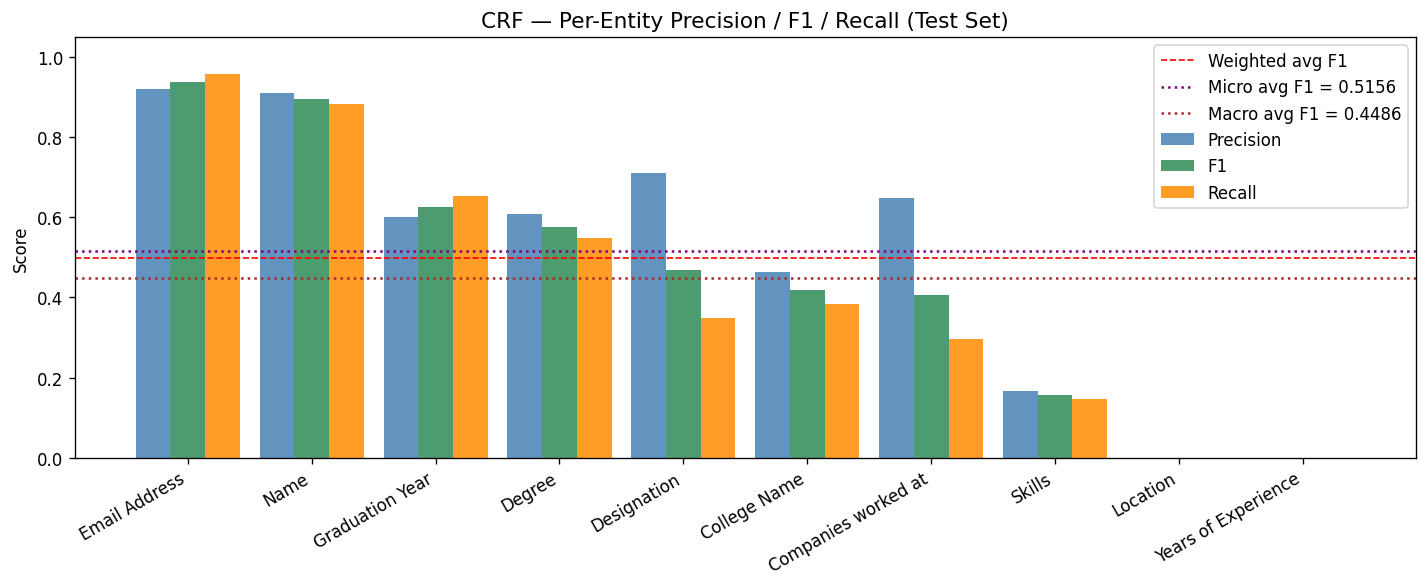

In [17]:
# Per-label F1 bar chart
from seqeval.metrics import classification_report as seq_report
import re as _re

report_str = seq_report(y_test, y_pred_test, digits=4, output_dict=False)
report_dict = seq_report(y_test, y_pred_test, digits=4, output_dict=True)

# Overall metrics
micro_f1    = report_dict['micro avg']['f1-score']
macro_f1    = report_dict['macro avg']['f1-score']

# Extract per-label rows (exclude micro/macro/weighted avg)
per_label = {
    k: v for k, v in report_dict.items()
    if isinstance(v, dict) and k not in ('micro avg','macro avg','weighted avg')
}

labels_sorted = sorted(per_label, key=lambda k: per_label[k]['f1-score'], reverse=True)
f1_scores     = [per_label[k]['f1-score'] for k in labels_sorted]
precision     = [per_label[k]['precision'] for k in labels_sorted]
recall        = [per_label[k]['recall']    for k in labels_sorted]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(labels_sorted))
w = 0.28
ax.bar([i - w for i in x], precision, width=w, label='Precision', color='steelblue', alpha=0.85)
ax.bar(list(x),            f1_scores, width=w, label='F1',        color='seagreen',  alpha=0.85)
ax.bar([i + w for i in x], recall,    width=w, label='Recall',    color='darkorange', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_sorted, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('CRF — Per-Entity Precision / F1 / Recall (Test Set)')
ax.axhline(report_dict.get('weighted avg', {}).get('f1-score', 0), color='red', linestyle='--', linewidth=1, label='Weighted avg F1')
ax.axhline(micro_f1, color='purple', linestyle=':', linewidth=1.5, label=f'Micro avg F1 = {micro_f1:.4f}')
ax.axhline(macro_f1, color='brown',  linestyle=':', linewidth=1.5, label=f'Macro avg F1 = {macro_f1:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

### Inference Demo

In [ ]:
# Minimal normalization (must match Preprocessing.ipynb)
_TECH = re.compile(r'[+#]|\d|\.\w|^[A-Z]{1,5}$|^\.[a-z]+')
def _norm(tok):
    is_tech = bool(_TECH.search(tok))
    t = unicodedata.normalize('NFKD', tok).encode('ascii','ignore').decode('ascii').lower()
    t = re.sub(r'^[^\w.#+]+|[^\w.#+]+$', '', t)
    if not t or re.match(r'^[^\w.#+]+$|^[\-\u2013\u2014]+$', t): return None
    return t


def predict_resume(text: str) -> list[tuple[str, str]]:
    """
    Run CRF inference on a raw resume text string.

    Returns list of (token, predicted_label) pairs.
    """
    # Tokenize
    raw_tokens = [(m.group(), m.start(), m.end()) for m in re.finditer(r'\S+', text)]
    raw_bio    = [(tok, 'O') for tok, _, _ in raw_tokens]   # dummy tags

    # Normalize
    norm_pairs = []
    for tok, tag in raw_bio:
        n = _norm(tok)
        if n: norm_pairs.append((n, tag))

    # Build parallel aligned list
    aligned = align_raw_norm(raw_bio, norm_pairs)
    raw_toks  = [r for r, _, _ in aligned]
    norm_toks = [n for _, n, _ in aligned]

    feats = [
        token_features(raw_toks[i], norm_toks[i], i, raw_toks, norm_toks)
        for i in range(len(aligned))
    ]

    pred_tags = crf_final.predict([feats])[0]
    return list(zip(norm_toks, pred_tags))


def extract_entities(predictions: list[tuple[str, str]]) -> dict:
    """Group BIO-tagged tokens into entity strings by label."""
    entities = {}
    current_toks, current_lbl = [], None
    for tok, tag in predictions:
        if tag.startswith('B-'):
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [tok], tag[2:]
        elif tag.startswith('I-') and current_toks:
            current_toks.append(tok)
        else:
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [], None
    if current_toks:
        entities.setdefault(current_lbl, []).append(' '.join(current_toks))
    return entities


# Run on a test resume
sample_content = '\n'.join(
    tok for tok, _ in processed[idx_test[0]]['word_bio_raw']
)
preds = predict_resume(sample_content)
entities = extract_entities(preds)

print('=== Extracted Entities (Test Resume 0) ===')
for lbl, values in entities.items():
    for v in values:
        print(f"{lbl:<25} -> {v[:70]}")

=== Extracted Entities (Test Resume 0) ===
Name                       -> dushyant bhatt
Skills                     -> back-up and recovery writing and optimizing sql code and stored proced
Skills                     -> microsoft edge and making purchases at the xbox store the windows stor
Skills                     -> maintains cordial relationship with project manager and team members a
Companies worked at        -> microsoft
